# Continuation of Transformer vs Linear Regression file 

In [3]:
## 1) Take equally spaced "x" and y is trend or sin(x), predict the next N_window steps

* Data:
  $y(t) = \sin(t) + noise $ for $t = 0, 0.1, ..., 10$
* Goal:
  Train a model to predict $y_{t+1}$ given previous $N$ time steps, i.e.,
  $[y_{t-N}, ..., y_t] \to y_{t+1}$
* Compare:
  * MLP (simple feedforward)
  * Transformer (sequence model)

## Load packages and simulate the data

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset, random_split

In [2]:
#--- 1. Generate Sine Wave Data
t = np.arange(0, 30, 0.1)
y = np.sin(t) + 0.10* np.random.normal(0,1,len(t))

#--- Prepare sequences with fixed window size - X_seq[[0]] is y from 0 till 9, y_seq[0] is y[10] etc.
window_size = 15
X_seq = []
y_seq = []
for i in range(len(y) - window_size):
    X_seq.append(y[i:i+window_size])
    y_seq.append(y[i+window_size])
X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

#--- Convert to torch tensors
X_tensor = torch.tensor(X_seq, dtype=torch.float32)
y_tensor = torch.tensor(y_seq, dtype=torch.float32)

#--- Train/test split random
#train_dataset, test_dataset = random_split(TensorDataset(X_tensor, y_tensor), [int(0.8 * len(full_dataset)), len(full_dataset) - train_size])

#--- Train/test split non-random
train_size = int(0.8 * len(X_tensor))
train_X, test_X = X_tensor[:train_size], X_tensor[train_size:]
train_y, test_y = y_tensor[:train_size], y_tensor[train_size:]


NameError: name 'np' is not defined

## Plot data

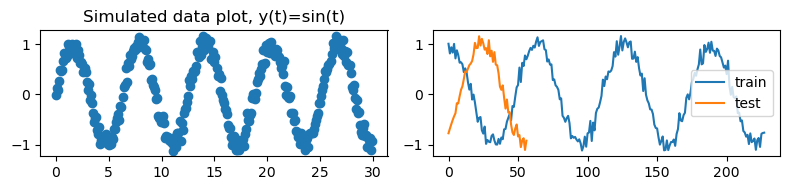

In [496]:
fig, axs = plt.subplots(1, 2, figsize=(8, 2))
axs[0].scatter(t,y)
axs[0].set_title("Simulated data plot, y(t)=sin(t)")
axs[1].plot(train_y, label = "train")
axs[1].plot(test_y, label = "test")
axs[1].legend()
plt.tight_layout()
plt.show()

## Models set up

In [499]:
# M1. Simple MLP Model
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 1)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x).squeeze(-1) 


In [507]:
# M2. Transformer Model
class TransformerRegressor(nn.Module):
    def __init__(self, input_len, d_model=32, nhead=2, num_layers=2):
        super().__init__()
        self.embedding = nn.Linear(1, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(d_model, 1)
    
    def forward(self, x):
        # x: (batch_size, seq_len)
        x = x.unsqueeze(-1)  # (batch_size, seq_len, 1)
        x = self.embedding(x)  # (batch_size, seq_len, d_model)
        x = x.permute(1, 0, 2)  # (seq_len, batch_size, d_model)
        x = self.transformer(x)  # (seq_len, batch_size, d_model)
        x = x[-1]  # take the last time step (batch_size, d_model)
        # alternative: x = x.mean(dim=0)  # mean pooling across seq_len -> (batch_size, d_model)
        return self.fc_out(x).squeeze(-1)

In [505]:
# M2. Transformer Model - alternative pooling, to predict the next y 
# not for the hidden state for the previous token but 
# but from a learnt average of representations of the tokens (we don't give positions, so may be better)

class TransformerRegressor2(nn.Module):
    def __init__(self, input_len, d_model=32, nhead=2, num_layers=2):
        super().__init__()
        self.embedding = nn.Linear(1, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Attention pooling parameters
        self.attn_weight = nn.Parameter(torch.randn(d_model))
        
        self.fc_out = nn.Linear(d_model, 1)
    
    def forward(self, x):
        # x: (batch_size, seq_len)
        x = x.unsqueeze(-1)  # (batch_size, seq_len, 1)
        x = self.embedding(x)  # (batch_size, seq_len, d_model)
        x = x.permute(1, 0, 2)  # (seq_len, batch_size, d_model)
        x = self.transformer(x)  # (seq_len, batch_size, d_model)

        # Attention pooling
        x = x.permute(1, 0, 2)  # (batch_size, seq_len, d_model)
        attn_scores = torch.tanh(x) @ self.attn_weight  # (batch_size, seq_len)
        attn_weights = F.softmax(attn_scores, dim=1)  # (batch_size, seq_len)
        z = torch.sum(x * attn_weights.unsqueeze(-1), dim=1)  # (batch_size, d_model)

        return self.fc_out(z).squeeze(-1)  # (batch_size,)


In [503]:
# M3.  RNN Model 
class SimpleRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=32):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc1 = nn.Linear(hidden_size, 16)
        self.fc2 = nn.Linear(16, 1)
    def forward(self, x):
        x = x.unsqueeze(-1)  # (batch, seq_len, 1)
        out, _ = self.rnn(x)
        last_out = out[:, -1, :]  # take last output
        x = F.relu(self.fc1(last_out))
        return self.fc2(x).squeeze(-1)

Given the model setup:

## Exact Formula — Step by Step

Input:

You provide a **sequence of past `y` values**:

$$
\mathbf{y} = [y_{t-N}, y_{t-N+1}, ..., y_t] \in \mathbb{R}^N
$$



### 1. **Input embedding:**

Each scalar $y_i$ is embedded to $\mathbf{e}_i \in \mathbb{R}^{16}$ via a linear projection:

$$
\mathbf{e}_i = W_{\text{emb}} \cdot y_i + b_{\text{emb}} \quad \text{for } i = t-N, \dots, t
$$

---

### 2. **Positional encoding (optional, can be omitted for simplicity or added as fixed vectors):**

$$
\mathbf{z}_i = \mathbf{e}_i + \mathbf{p}_i
$$

---

### 3. **Self-attention (for all tokens in the window):**

Compute **queries, keys, values**:

$$
\mathbf{q}_i = W^Q \mathbf{z}_i, \quad \mathbf{k}_j = W^K \mathbf{z}_j, \quad \mathbf{v}_j = W^V \mathbf{z}_j
$$

where $W^Q, W^K, W^V \in \mathbb{R}^{16 \times 16}$

Compute **attention weights**:

$$
\alpha_{ij} = \frac{ \mathbf{q}_i^\top \mathbf{k}_j }{ \sqrt{16} }, \quad \text{softmax over } j
$$

$$
\text{Attention output: } \mathbf{h}_i = \sum_j \text{softmax}(\alpha_{ij}) \cdot \mathbf{v}_j
$$

---

### 4. **Feed-forward output (per token):**

$$
\mathbf{o}_i = W_2 \cdot \text{ReLU}(W_1 \cdot \mathbf{h}_i + b_1) + b_2
$$

$W_1 \in \mathbb{R}^{16 \times 16}, W_2 \in \mathbb{R}^{16 \times 16}$

---

### 5. **Final output: predict $\hat{y}_{t+1}$ from the last token:**

$$
\hat{y}_{t+1} = w_{\text{out}}^\top \mathbf{o}_t + b_{\text{out}} \quad \text{where } w_{\text{out}} \in \mathbb{R}^{16}
$$

---

### Overall:

$$
\hat{y}_{t+1} = f_\theta(y_{t-N}, \dots, y_t)
$$

where $f_\theta$ includes **embedding**, **attention**, **feedforward**, and **output projection**, all parameterized by $\theta$.


## Train function

In [435]:
# 4. Train Function
def train_model(model, train_loader, test_loader, epochs=100, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for xb, yb in train_loader:
            pred = model(xb)
            loss = loss_fn(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
        avg_train_loss = total_loss / len(train_loader.dataset)
        train_losses.append(avg_train_loss)

        # Evaluate
        model.eval()
        with torch.no_grad():
            preds, targets = [], []
            for xb, yb in test_loader:
                pred = model(xb)
                preds.append(pred)
                targets.append(yb)
            preds = torch.cat(preds)
            targets = torch.cat(targets)
            test_loss = loss_fn(preds, targets).item()
            test_losses.append(test_loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}: Train Loss={avg_train_loss:.4f}, Test Loss={test_loss:.4f}")

    return train_losses, test_losses, preds, targets

## Test

In [528]:
if window_size >50: 
    batch_size= 64
elif window_size > 30: 
    batch_size= 32
else: batch_size= 16
print( f'window size = {window_size}, batch_size = {batch_size}')

window size = 15, batch_size = 16


In [549]:
len(train_X)

228

In [530]:
#--- DataLoaders
train_loader = DataLoader(TensorDataset(train_X, train_y), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(test_X, test_y), batch_size=batch_size)

In [532]:
mlp = MLP(input_dim = X_tensor.shape[1])
mse0_mlp, mse_mlp, pred_mlp, tgt_mlp = train_model(mlp, train_loader, test_loader, epochs = 100, lr = 1e-3)
#print(f"MLP MSE: {mse_mlp[len(mse_mlp)-1]:.4f}")

Epoch 0: Train Loss=0.3971, Test Loss=0.2370
Epoch 10: Train Loss=0.0125, Test Loss=0.0122
Epoch 20: Train Loss=0.0110, Test Loss=0.0135
Epoch 30: Train Loss=0.0112, Test Loss=0.0136
Epoch 40: Train Loss=0.0113, Test Loss=0.0142
Epoch 50: Train Loss=0.0111, Test Loss=0.0147
Epoch 60: Train Loss=0.0096, Test Loss=0.0142
Epoch 70: Train Loss=0.0096, Test Loss=0.0154
Epoch 80: Train Loss=0.0091, Test Loss=0.0152
Epoch 90: Train Loss=0.0090, Test Loss=0.0150


In [534]:
rnn = SimpleRNN()
mse0_rnn, mse_rnn, pred_rnn, tgt_rnn = train_model(rnn, train_loader, test_loader, epochs = 100, lr = 1e-2)
print(f"RNNP MSE: {mse_rnn[len(mse_rnn)-1]:.4f}")

Epoch 0: Train Loss=0.1610, Test Loss=0.0506
Epoch 10: Train Loss=0.0207, Test Loss=0.0328
Epoch 20: Train Loss=0.0298, Test Loss=0.0249
Epoch 30: Train Loss=0.0189, Test Loss=0.0175
Epoch 40: Train Loss=0.0164, Test Loss=0.0195
Epoch 50: Train Loss=0.0225, Test Loss=0.0198
Epoch 60: Train Loss=0.0289, Test Loss=0.0229
Epoch 70: Train Loss=0.0177, Test Loss=0.0192
Epoch 80: Train Loss=0.0184, Test Loss=0.0159
Epoch 90: Train Loss=0.0194, Test Loss=0.0159
RNNP MSE: 0.0167


In [535]:
transformer = TransformerRegressor(window_size)
mse0_trans,mse_trans, pred_trans, tgt_rnn = train_model(transformer, train_loader, test_loader, epochs = 50, lr = 1e-3)
print(f"Transformer MSE: {mse_trans[len(mse_trans)-1]:.4f}")


Epoch 0: Train Loss=0.2103, Test Loss=0.0506
Epoch 10: Train Loss=0.0264, Test Loss=0.0158
Epoch 20: Train Loss=0.0246, Test Loss=0.0158
Epoch 30: Train Loss=0.0244, Test Loss=0.0161
Epoch 40: Train Loss=0.0222, Test Loss=0.0137
Transformer MSE: 0.0172


In [542]:
transformer2 = TransformerRegressor2(window_size)
mse0_trans,mse_trans, pred_trans, tgt_rnn = train_model(transformer2, train_loader, test_loader, epochs = 100, lr = 1e-3)
print(f"Transformer MSE: {mse_trans[len(mse_trans)-1]:.4f}")

Epoch 0: Train Loss=0.8303, Test Loss=0.2925
Epoch 10: Train Loss=0.3105, Test Loss=0.3248
Epoch 20: Train Loss=0.2586, Test Loss=0.2843
Epoch 30: Train Loss=0.2515, Test Loss=0.2833
Epoch 40: Train Loss=0.2664, Test Loss=0.3636
Epoch 50: Train Loss=0.2663, Test Loss=0.4262
Epoch 60: Train Loss=0.2687, Test Loss=0.3314
Epoch 70: Train Loss=0.2649, Test Loss=0.3744
Epoch 80: Train Loss=0.2314, Test Loss=0.4029
Epoch 90: Train Loss=0.2497, Test Loss=0.3540
Transformer MSE: 0.4163


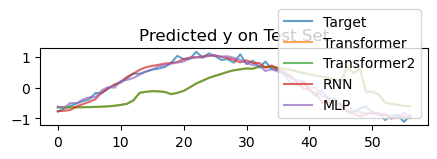

In [551]:
# --- Plot predictions ---
plt.figure(figsize=(5, 1))
plt.plot(tgt_rnn.numpy(), label='Target', alpha=0.7)
plt.plot(pred_trans.numpy(), label='Transformer', alpha=0.7)
plt.plot(pred_trans.numpy(), label='Transformer2', alpha=0.7)
plt.plot(pred_rnn.numpy(), label='RNN', alpha=0.7)
plt.plot(pred_mlp.numpy(), label='MLP', alpha=0.7)
plt.title("Predicted y on Test Set")
plt.legend()
plt.show()

In [555]:
mlp.eval()
transformer.eval()
rnn.eval()
with torch.no_grad():
    pred1 =mlp(X_tensor)  
    pred2 =transformer(X_tensor) 
    pred2b =transformer2(X_tensor) 
    pred3 = rnn(X_tensor) 
pred1 = pred1.cpu().numpy()
pred2 = pred2.cpu().numpy()
pred2b = pred2b.cpu().numpy()
pred3 = pred3.cpu().numpy()

In [447]:
# check if predicts similar to the last point 
from scipy.stats import pearsonr
a = [X_seq[i][-1] for i in range(300-window_size)]
diff1 = np.abs(a - pred1) 
diff2 = np.abs(a - pred2) 
diff3 = np.abs(a - pred3) 
corr1, _ = pearsonr(a, diff1)
corr2, _ = pearsonr(a, diff2)
corr3, _ = pearsonr(a, diff3)
print (f"Correlation of next prediction and last input: {corr1:.4f}, {corr2:.4f},{corr3:.4f}")

Correlation of next prediction and last input: 0.1084, 0.1949,0.2797


## Plot predictions 

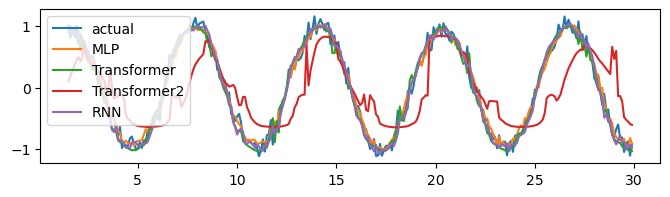

In [558]:
plt.figure(figsize=(8, 2))
plt.plot(t[window_size:], y[window_size:], label = "actual")
plt.plot(t[window_size:], pred1, label = "MLP")
plt.plot(t[window_size:], pred2, label = "Transformer")
plt.plot(t[window_size:], pred2b, label = "Transformer2")
plt.plot(t[window_size:], pred3, label = "RNN")
plt.legend()

## Generate future predictions 

In [456]:
def predict_future(model, future_steps=10, device='cpu', start_n=300, printval = False):
    # Start with  known values before the "start_n"
    current_seq = list(y[start_n-window_size:start_n])  # Python list for easy appending
    if (printval): print (current_seq)
    predictions = []
    model.eval()  
    with torch.no_grad():
        # loop by future steps
        for _ in range(future_steps):
            # Prepare input tensor of shape (1, window_size)
            input_tensor = torch.tensor(current_seq[-window_size:], dtype=torch.float32).unsqueeze(0)         
            # Predict next value
            next_val = model(input_tensor).item()  # for MLP; similarly for Transformer/RNN
            if (printval): print(next_val)
            predictions.append(next_val)
            current_seq.append(next_val)  # Add to sequence for next step
    # Convert predictions to numpy for plotting
    preds_array = np.array(predictions)
    return (preds_array)

In [560]:
# generate predictons for a number of future_steps from different starting points start_ns
start_ns = [50, 75, 160, 185 ,220]
future_steps = 75
a1 = []; a2 = []; a3 = []; a2b = []
for start_n in start_ns:
    a1.append(predict_future(mlp, future_steps = future_steps, printval= False, start_n = start_n))
    a2.append(predict_future(transformer, future_steps = future_steps, printval= False, start_n = start_n))
    a2b.append(predict_future(transformer2, future_steps = future_steps, printval= False, start_n = start_n))
    a3.append(predict_future(rnn, future_steps = future_steps, printval= False, start_n = start_n))

### window size = 15 steps  * 0.1 step size = 1.5

[50, 75, 160, 185, 220]
Window size = (15, 1.5)


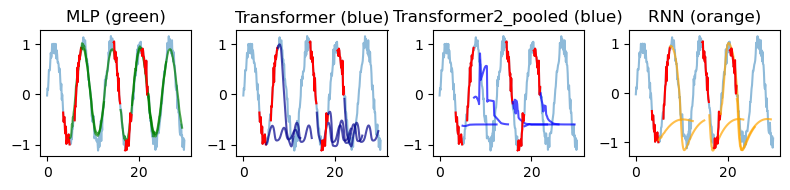

In [570]:
# window size = 15 steps  * 0.1 step size = 1.5
# plot predictions 
print(start_ns)
print (f"Window size = {window_size, window_size*0.1}")
fig, axs = plt.subplots(1, 4, figsize=(8, 2))
#axs[0].set_title("Generated future trajectories, mlp(green), transformer(blue), RNN (orange)")
axs[0].set_title("MLP (green)")
axs[1].set_title("Transformer (blue)")
axs[2].set_title("Transformer2_pooled (blue)")
axs[3].set_title("RNN (orange)")
axs[0].plot(t,y, alpha = 0.5)
axs[1].plot(t,y, alpha = 0.5)
axs[2].plot(t,y, alpha = 0.5)
axs[3].plot(t,y, alpha = 0.5)
for i in range(len(start_ns)):
    axs[0].plot(t[start_ns[i]-window_size:start_ns[i]], y[start_ns[i]-window_size:start_ns[i]], color = "red")
    axs[0].plot(t[start_ns[i]: start_ns[i] + future_steps], a1[i], color = "green", alpha = 0.7)   
    axs[1].plot(t[start_ns[i]-window_size:start_ns[i]], y[start_ns[i]-window_size:start_ns[i]], color = "red")
    axs[1].plot(t[start_ns[i]: start_ns[i] + future_steps], a2[i], color = "darkblue", alpha = 0.7)   
    axs[2].plot(t[start_ns[i]-window_size:start_ns[i]], y[start_ns[i]-window_size:start_ns[i]], color = "red")
    axs[2].plot(t[start_ns[i]: start_ns[i] + future_steps], a2b[i], color = "blue", alpha = 0.7)   
    axs[3].plot(t[start_ns[i]-window_size:start_ns[i]], y[start_ns[i]-window_size:start_ns[i]], color = "red")
    axs[3].plot(t[start_ns[i]: start_ns[i] + future_steps], a3[i], color = "orange", alpha = 0.7)   
plt.tight_layout()
plt.show()

### window size = 50 steps  * 0.1 step size = 5.0

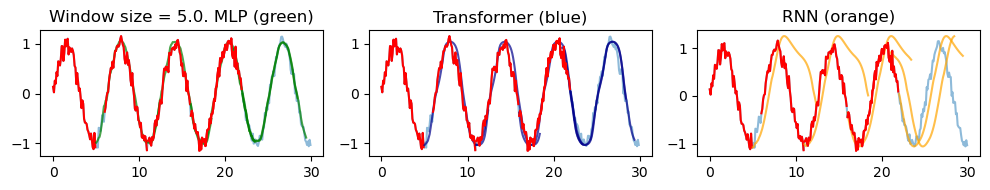

In [376]:
# window size = 50 steps  * 0.1 step size = 5.0
# plot predictions 
print (f"Window size = {window_size, window_size*0.1}")
fig, axs = plt.subplots(1, 3, figsize=(10, 2))
#axs[0].set_title("Generated future trajectories, mlp(green), transformer(blue), RNN (orange)")
axs[0].set_title(f"Window size = {window_size*0.1}. MLP (green)")
axs[1].set_title("Transformer (blue)")
axs[2].set_title("RNN (orange)")
axs[0].plot(t,y, alpha = 0.5)
axs[1].plot(t,y, alpha = 0.5)
axs[2].plot(t,y, alpha = 0.5)
for i in range(len(start_ns)):
    axs[0].plot(t[start_ns[i]-window_size:start_ns[i]], y[start_ns[i]-window_size:start_ns[i]], color = "red")
    axs[0].plot(t[start_ns[i]: start_ns[i] + future_steps], a1[i], color = "green", alpha = 0.7)   
    axs[1].plot(t[start_ns[i]-window_size:start_ns[i]], y[start_ns[i]-window_size:start_ns[i]], color = "red")
    axs[1].plot(t[start_ns[i]: start_ns[i] + future_steps], a2[i], color = "darkblue", alpha = 0.7)   
    axs[2].plot(t[start_ns[i]-window_size:start_ns[i]], y[start_ns[i]-window_size:start_ns[i]], color = "red")
    axs[2].plot(t[start_ns[i]: start_ns[i] + future_steps], a3[i], color = "orange", alpha = 0.7)   
plt.tight_layout()
plt.show()

### window size = 30 steps  * 0.1 step size = 3.0

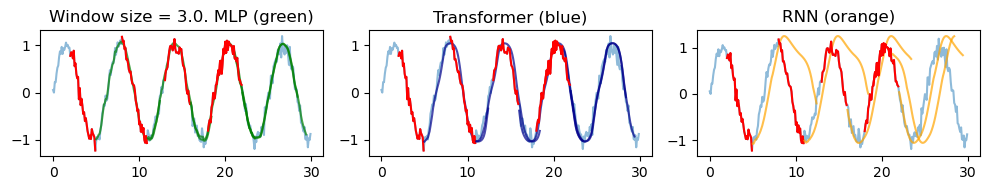

In [346]:
# window size = 30 steps  * 0.1 step size = 3.0
# plot predictions 
print (f"Window size = {window_size, window_size*0.1}")
fig, axs = plt.subplots(1, 3, figsize=(10, 2))
#axs[0].set_title("Generated future trajectories, mlp(green), transformer(blue), RNN (orange)")
axs[0].set_title(f"Window size = {window_size*0.1}. MLP (green)")
axs[1].set_title("Transformer (blue)")
axs[2].set_title("RNN (orange)")
axs[0].plot(t,y, alpha = 0.5)
axs[1].plot(t,y, alpha = 0.5)
axs[2].plot(t,y, alpha = 0.5)
for i in range(len(start_ns)):
    axs[0].plot(t[start_ns[i]-window_size:start_ns[i]], y[start_ns[i]-window_size:start_ns[i]], color = "red")
    axs[0].plot(t[start_ns[i]: start_ns[i] + future_steps], a1[i], color = "green", alpha = 0.7)   
    axs[1].plot(t[start_ns[i]-window_size:start_ns[i]], y[start_ns[i]-window_size:start_ns[i]], color = "red")
    axs[1].plot(t[start_ns[i]: start_ns[i] + future_steps], a2[i], color = "darkblue", alpha = 0.7)   
    axs[2].plot(t[start_ns[i]-window_size:start_ns[i]], y[start_ns[i]-window_size:start_ns[i]], color = "red")
    axs[2].plot(t[start_ns[i]: start_ns[i] + future_steps], a3[i], color = "orange", alpha = 0.7)   
plt.tight_layout()
plt.show()
